# Tutorial 3: Spatial Proteomics Analysis of Tumor Microenvironment

This tutorial demonstrates multi-condition spatial analysis using CODEX spatial proteomics data
from colorectal cancer (CRC) tissue. The dataset contains two immune subtypes — CLR (Crohn's-Like Reaction)
and DII (Diffuse Inflammatory Infiltration) — each with multiple fields of view (FOVs).

We use `spatial_query_multi` to compare spatial motif patterns between conditions, perform differential
motif analysis, and examine hypothesis-driven motifs such as tertiary lymphoid structures (TLS)
and immunosuppressive niches.

**API class:** `spatial_query_multi`

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from SpatialQuery import spatial_query_multi

## 2. Load & Preprocess Data

The CODEX data contains raw protein intensities. We assign disease state labels, apply z-score
normalization, and split by FOV for multi-dataset analysis.

In [3]:
# ---- Configuration: adjust these to match your dataset ----
DATA_DIR = "../data/codex_cancer"

adata = ad.read_h5ad(f"{DATA_DIR}/codex_data.h5ad")

adata

AnnData object with n_obs × n_vars = 258385 × 56
    obs: 'CellID', 'ClusterID', 'EventID', 'File Name', 'Region', 'TMA_AB', 'TMA_12', 'Index in File', 'groups', 'patients', 'spots', 'cell_id', 'size:size', 'HOECHST1_Cyc_1_ch_1', 'DRAQ5_Cyc_23_ch_4', 'Profile_Homogeneity:Fiter1', 'ClusterSize', 'ClusterName', 'neighborhood10', 'CD4+ICOS+', 'CD4+Ki67+', 'CD4+PD-1+', 'CD68+CD163+ICOS+', 'CD68+CD163+Ki67+', 'CD68+CD163+PD-1+', 'CD68+ICOS+', 'CD68+Ki67+', 'CD68+PD-1+', 'CD8+ICOS+', 'CD8+Ki67+', 'CD8+PD-1+', 'Treg-ICOS+', 'Treg-Ki67+', 'Treg-PD-1+', 'neighborhood number final', 'neighborhood name'
    var: 'marker_name', 'full_name', 'cell_type_annotation', 'cycle', 'channel'
    uns: 'data_source', 'groups_mapping', 'n_markers', 'technology'
    obsm: 'X_spatial_global', 'X_spatial_tile'

In [4]:
# Assign immune subtype labels based on group ID
adata.obs["state"] = "CLR"
adata.obs["state"][adata.obs["groups"] == 2] = "DII"

print(f"Max value: {adata.X.max()}")

Max value: 54776.6953125


In [5]:
# Feature-wise z-score normalization for protein expression
adata.X = (adata.X - adata.X.mean(axis=0)) / adata.X.std(axis=0)

In [6]:
# Split data by FOV and immune subtype
fov_key = "File Name"

clr_data = adata[adata.obs["state"] == "CLR"]
dii_data = adata[adata.obs["state"] == "DII"]

clr_datas = [clr_data[clr_data.obs[fov_key] == f] for f in clr_data.obs[fov_key].unique()]
dii_datas = [dii_data[dii_data.obs[fov_key] == f] for f in dii_data.obs[fov_key].unique()]

ds_names = ["CLR"] * len(clr_datas) + ["DII"] * len(dii_datas)
adata_fovs = clr_datas + dii_datas

## 3. Initialize SpatialQuery Multi

Since this is protein data is z-score normalized, we set `if_lognorm=False`.

In [7]:
# ---- Configuration: adjust these to match your dataset ----
spatial_key = "X_spatial_tile"
label_key = "ClusterName"
feature_name = "marker_name"

In [8]:
spm = spatial_query_multi(
    adatas=adata_fovs,
    datasets=ds_names,
    spatial_key=spatial_key,
    label_key=label_key,
    feature_name=feature_name,
    build_gene_index=False,
    if_lognorm=False,              # data is z-score normalized beforehand
    if_normalize_spatial_coord=True,
)


Auto-normalizing spatial coordinates: mean nearest neighbor distance = 1.0
Scale factor: 0.0448
build_gene_index is False. Using adata.X for gene expression analysis.

Auto-normalizing spatial coordinates: mean nearest neighbor distance = 1.0
Scale factor: 0.0311
build_gene_index is False. Using adata.X for gene expression analysis.

Auto-normalizing spatial coordinates: mean nearest neighbor distance = 1.0
... (548 lines omitted) ...
Scale factor: 0.0421
build_gene_index is False. Using adata.X for gene expression analysis.


## 4. Cell Type Composition

/var/folders/wl/y90xsxr94l78931lqz6nyvz80000gp/T/ipykernel_18164/676858651.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(name)
/var/folders/wl/y90xsxr94l78931lqz6nyvz80000gp/T/ipykernel_18164/676858651.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(name)
/Users/sa3520/BWH/spatial query/python/SpatialQuery/spatial_query_multiple_fov.py:1441: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)

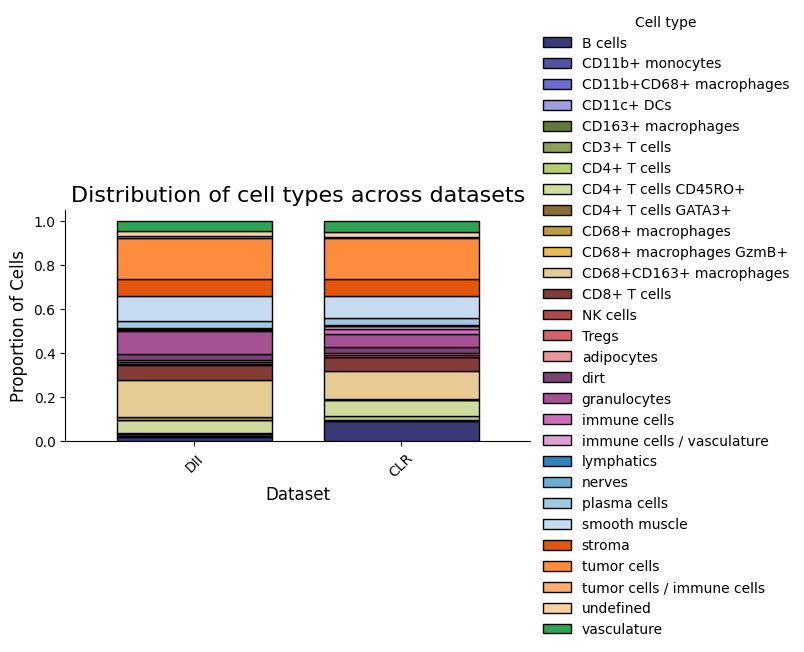

In [9]:
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

# Combine tab20b + tab20c for 40 unique colors
all_colors = []
for name in ["tab20b", "tab20c"]:
    cmap = cm.get_cmap(name)
    all_colors.extend([cmap(i) for i in range(cmap.N)])

seen = set()
unique_colors = []
for c in all_colors:
    key = tuple(round(v, 4) for v in c)
    if key not in seen:
        seen.add(key)
        unique_colors.append(c)

custom_cmap = ListedColormap(unique_colors, name="tab40")

spm.plot_cell_type_distribution(colormap=custom_cmap)

## 5. Motif Enrichment by Condition

Discover enriched motifs surrounding **B cells** in each immune subtype separately,
then compare the results side by side.

In [10]:
anchor_ct = 'B cells'
max_dist = 5
min_support = 0.5

clr = 'CLR'
dii = 'DII'

enrich_motif_dataset = dict()

for ds in [clr, dii]:
    enrich_motif_dataset[ds] = spm.motif_enrichment_dist(
        ct=anchor_ct,
        dataset=ds,
        max_dist=max_dist,
        min_support=min_support,
        return_cellID=False
    )
    enrich_motif_dataset[ds] = enrich_motif_dataset[ds][enrich_motif_dataset[ds]['if_significant']]
    print(f"Found {len(enrich_motif_dataset[ds])} enriched motifs in {ds}")
    
enrich_motif_dataset_df = pd.DataFrame()
for ds, df in enrich_motif_dataset.items():
    df['dataset'] = ds
    enrich_motif_dataset_df = pd.concat([enrich_motif_dataset_df, df], axis=0)
    

Found 2 enriched motifs in CLR
Found 14 enriched motifs in DII


In [11]:
enrich_motif_dataset_df

,center,motifs,n_center_motif,n_center,n_motif,expectation,p-values,adj-pval,if_significant,dataset
0,B cells,"[B cells, CD4+ T cells CD45RO+, CD8+ T cells]",6680,10269,27291,2523.399564,0.000000e+00,0.000000e+00,True,CLR
1,B cells,"[B cells, tumor cells]",5382,10269,24255,2242.682805,0.000000e+00,0.000000e+00,True,CLR
0,B cells,"[B cells, CD8+ T cells]",1704,2774,26742,503.531726,0.000000e+00,0.000000e+00,True,DII
1,B cells,"[B cells, CD4+ T cells CD45RO+]",1647,2774,24170,455.102902,0.000000e+00,0.000000e+00,True,DII
2,B cells,"[B cells, stroma]",1592,2774,26083,491.123252,0.000000e+00,0.000000e+00,True,DII
3,B cells,"[B cells, CD68+CD163+ macrophages]",1495,2774,30610,576.363254,0.000000e+00,0.000000e+00,True,DII
4,B cells,"[B cells, smooth muscle]",1425,2774,19963,375.888260,0.000000e+00,0.000000e+00,True,DII
5,B cells,"[CD4+ T cells CD45RO+, CD8+ T cells]",1668,2774,58370,1099.063153,1.527325e-107,3.818311e-107,True,DII
6,B cells,"[CD8+ T cells, smooth muscle]",1393,2774,47767,899.416646,1.183362e-85,2.535775e-85,True,DII
7,B cells,"[CD4+ T cells CD45RO+, stroma]",1566,2774,57711,1086.654679,3.314561e-77,6.214802e-77,True,DII


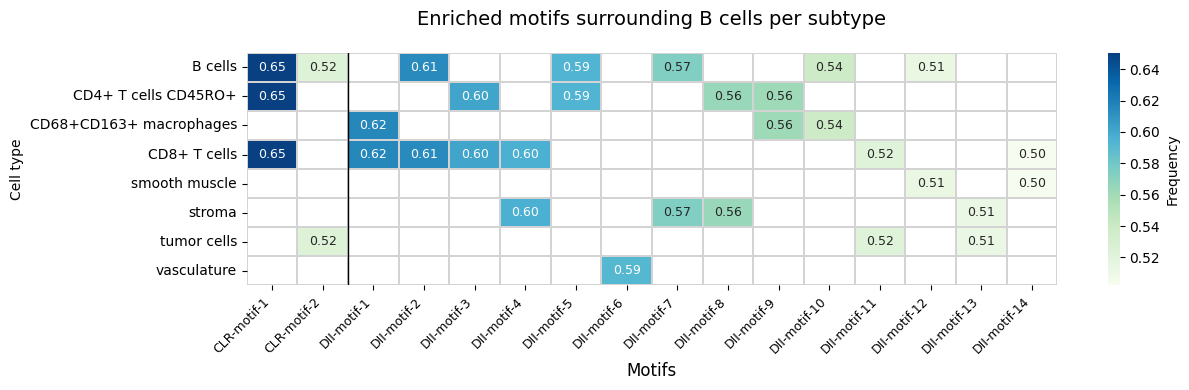

In [12]:
enrich = enrich_motif_dataset_df.copy()
enrich["frequency"] = enrich["n_center_motif"] / enrich["n_center"]

# Sort by dataset, then by frequency within each dataset
enrich = enrich.sort_values(by=["dataset", "frequency"], ascending=[True, False]).reset_index(drop=True)

# Assign motif labels per dataset
enrich["motif_num"] = enrich.groupby("dataset").cumcount() + 1
enrich["motif_group"] = enrich["dataset"] + "_motif_" + enrich["motif_num"].astype(str)

# Build heatmap: cell types × motif groups
enrich_expanded = enrich.explode("motifs")
heatmap_data = enrich_expanded.pivot_table(
    index="motifs", columns="motif_group", values="frequency", aggfunc="first"
)

col_order = enrich["motif_group"].tolist()
heatmap_data = heatmap_data[col_order]
heatmap_data.columns = [col.replace("_", "-") for col in heatmap_data.columns]

# Reorder columns by dataset
clr, dii = "CLR", "DII"
col_order_reordered = []
for ds in [clr, dii]:
    col_order_reordered.extend([c for c in heatmap_data.columns if c.startswith(ds)])
heatmap_data = heatmap_data.loc[:, col_order_reordered]

# Find dataset boundaries for separator lines
boundaries = []
prev_dataset = None
for i, col in enumerate(col_order_reordered):
    current_dataset = col.split("-motif")[0]
    if prev_dataset is not None and current_dataset != prev_dataset:
        boundaries.append(i)
    prev_dataset = current_dataset

# Plot
fig, ax = plt.subplots(figsize=(max(8, len(col_order_reordered) * 0.8), max(4, len(heatmap_data) * 0.45)))
sns.heatmap(
    heatmap_data, cmap="GnBu", linewidths=0.1, linecolor="lightgrey",
    annot=True, fmt=".2f", annot_kws={"fontsize": 9},
    cbar_kws={"label": "Frequency"}, ax=ax,
)
for b in boundaries:
    ax.axvline(x=b, color="black", linewidth=1)

plt.title(f"Enriched motifs surrounding {anchor_ct} per subtype", fontsize=14, pad=20)
plt.ylabel("Cell type")
plt.xlabel("Motifs", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

## 6. Targeted Motif Analysis: Tertiary Lymphoid Structures (TLS)

TLS are organized immune aggregates associated with anti-tumor immunity. We test a TLS-associated
motif (B cells + T cell subsets) and visualize the FOVs with the highest motif frequency.

In [13]:
motif_tls = ["B cells", "CD4+ T cells", "CD4+ T cells CD45RO+", "CD8+ T cells"]

motif_bcell, id_motif, id_center = spm.motif_enrichment_dist(
    ct=anchor_ct,
    motifs=motif_tls,
    dataset=clr,
    max_dist=max_dist,
    return_cellID=True
)


In [14]:
freq = {
    clr: [],
}
freq_ds_names = {
    clr: [],
}

for sp in spm.spatial_queries:
    sp_ds_name = sp.dataset.split('_')[0]
    if sp_ds_name == clr:
        if anchor_ct not in sp.labels.values:
            continue
        
        out = sp.motif_enrichment_dist(
            ct=anchor_ct,
            motifs=motif_tls,
            max_dist=max_dist,
            return_cellID=False            
        )
        if len(out) == 0:
            continue
        ratio = out['n_center_motif'] / out['n_center']

        if isinstance(ratio, (pd.Series, np.ndarray)):
            ratio = ratio.iloc[0] if hasattr(ratio, "iloc") else ratio.item()

        ratio = float(ratio)

        freq[sp_ds_name].append(ratio)
        freq_ds_names[sp_ds_name].append(sp.dataset)

Found no ['CD4+ T cells'] in ClusterName. Ignoring them.
Found no ['CD4+ T cells'] in ClusterName. Ignoring them.
Found no ['CD4+ T cells'] in ClusterName. Ignoring them.
Found no ['CD4+ T cells'] in ClusterName. Ignoring them.
Found no ['CD4+ T cells'] in ClusterName. Ignoring them.
Found no ['CD4+ T cells'] in ClusterName. Ignoring them.
Found no ['CD4+ T cells'] in ClusterName. Ignoring them.
Found no ['CD4+ T cells'] in ClusterName. Ignoring them.
Found no ['CD4+ T cells'] in ClusterName. Ignoring them.
Found no ['CD4+ T cells'] in ClusterName. Ignoring them.
... (16 lines omitted) ...
Found no ['CD4+ T cells'] in ClusterName. Ignoring them.
Found no ['CD4+ T cells'] in ClusterName. Ignoring them.


In [15]:
def get_top3_names(freq, freq_ds_names, k=3):
    """Return dataset names of the top-k FOVs by motif frequency."""
    result = {}
    for key in freq:
        paired = sorted(zip(freq[key], freq_ds_names[key]), reverse=True)[:k]
        result[key] = [name for _, name in paired]
    return result

top3 = get_top3_names(freq, freq_ds_names)
top3

{'CLR': ['CLR_20', 'CLR_14', 'CLR_28']}

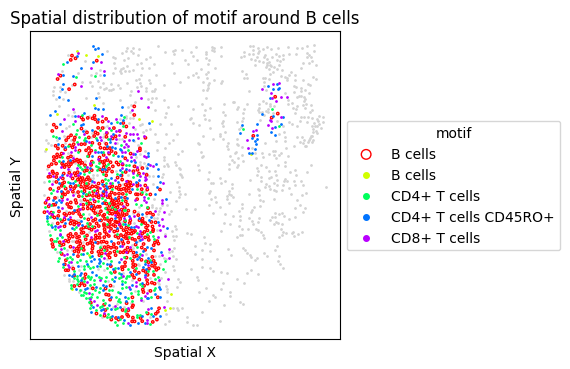

Found no ['CD4+ T cells'] in ClusterName. Ignoring them.


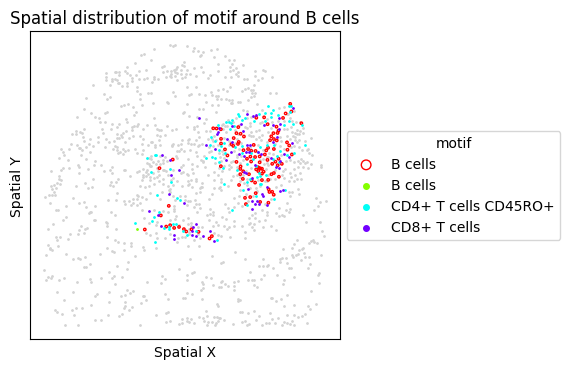

Found no ['CD4+ T cells'] in ClusterName. Ignoring them.


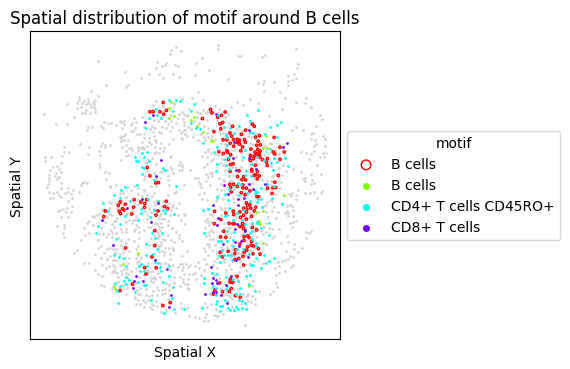

In [16]:

for sp in spm.spatial_queries:
    if sp.dataset in top3[clr]:
        sp.plot_motif_celltype(
            ct=anchor_ct,
            motif=motif_tls,
            max_dist=max_dist,
            figsize=(4, 4),
        )

## 7. Differential Motif Analysis

Identify motifs whose frequency differs significantly between CLR and DII subtypes
using `differential_analysis_dist`.

In [17]:
diff_motif_bcell = spm.differential_analysis_dist(
    ct=anchor_ct, 
    datasets=[clr, dii],
    max_dist=max_dist,
    min_support=min_support
)

Discovered 501 motifs across the datasets for differential analysis.


In [18]:
diff_motif_bcell[clr]

,itemsets,support_CLR_mean,support_DII_mean,adj-pval


In [19]:
diff_motif_bcell[dii]

,itemsets,support_CLR_mean,support_DII_mean,adj-pval
0,"(CD8+ T cells, Tregs, smooth muscle)",0.050989,0.146879,0.003753
1,"(CD68+CD163+ macrophages, CD8+ T cells, Tregs,...",0.048059,0.138878,0.003753
2,"(CD68+CD163+ macrophages, Tregs, granulocytes,...",0.041341,0.098820,0.019282
3,"(CD68+CD163+ macrophages, Tregs)",0.159009,0.302162,0.025271


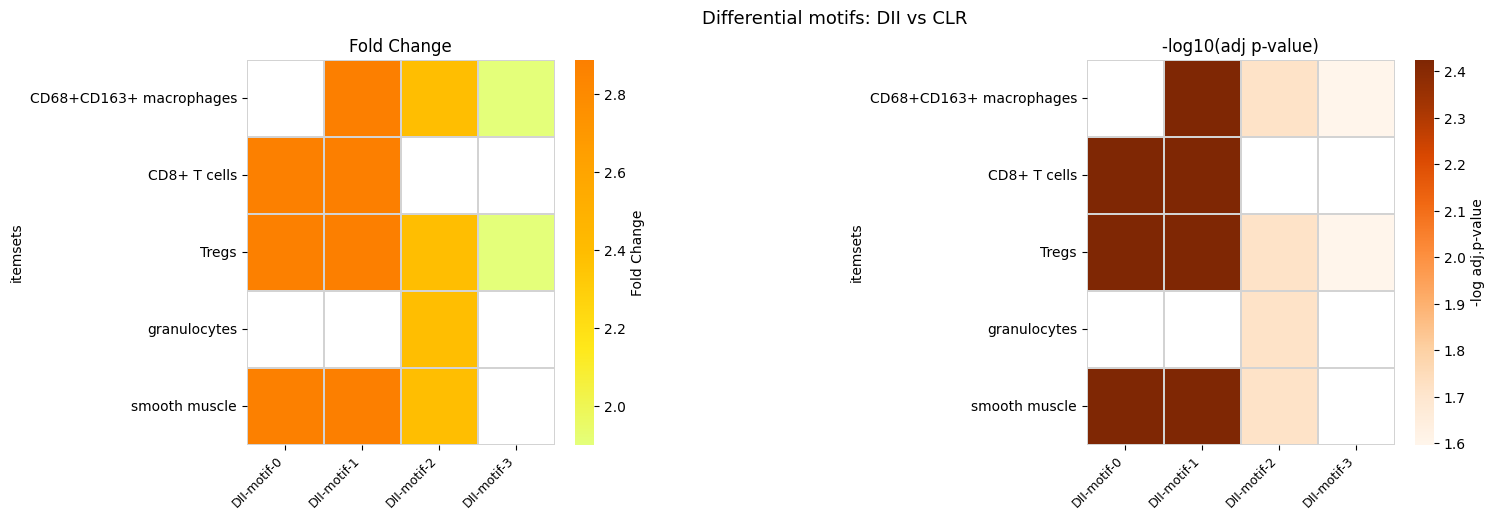

In [20]:
diff_motif_bcell[clr]['group'] = clr
diff_motif_bcell[dii]['group'] = dii

enrich = diff_motif_bcell[dii]
enrich = pd.concat([enrich, diff_motif_bcell[clr]], axis=0)

enrich['fold_change'] = enrich[f'support_{dii}_mean'] / enrich[f'support_{clr}_mean']

enrich['motif_group'] = enrich['group'] + '_motif_' + enrich.index.astype(str)
col_order = enrich['motif_group'].tolist()

enrich_expanded = enrich.explode('itemsets')

heatmap_fc = enrich_expanded.pivot_table(
    index='itemsets', columns='motif_group', values='fold_change'
)[col_order]

heatmap_pval = enrich_expanded.pivot_table(
    index='itemsets', columns='motif_group', values='adj-pval'
)
heatmap_pval = -np.log10(heatmap_pval)[col_order]

col_labels = [c.replace('_', '-') for c in col_order]
heatmap_fc.columns = col_labels
heatmap_pval.columns = col_labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'wspace': 1.1})

sns.heatmap(heatmap_fc, cmap='Wistia', linewidths=0.1, linecolor='lightgrey',
            square=True, cbar_kws={'label': 'Fold Change'}, ax=ax1)
ax1.set_title('Fold Change')
ax1.set_xlabel('')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=9)

sns.heatmap(heatmap_pval, cmap='Oranges', linewidths=0.1, linecolor='lightgrey',
            square=True, cbar_kws={'label': '-log adj.p-value'}, ax=ax2)
ax2.set_title('-log10(adj p-value)')
ax2.set_xlabel('')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=9)

fig.suptitle(f'Differential motifs: {dii} vs {clr}', fontsize=13)
plt.tight_layout()
plt.show()


## 8. Targeted Motif Analysis: Immunosuppressive Niche

Test a hypothesis-driven immunosuppressive motif (macrophages + Tregs + CD8+ T cells + granulocytes)
and compare its enrichment between CLR and DII.

In [21]:
motif_immsup = ["CD68+CD163+ macrophages", "Tregs", "CD8+ T cells", "granulocytes"]

immsup_clr = spm.motif_enrichment_dist(ct=anchor_ct, motifs=motif_immsup, max_dist=max_dist, dataset=clr)
immsup_dii = spm.motif_enrichment_dist(ct=anchor_ct, motifs=motif_immsup, max_dist=max_dist, dataset=dii)

immsup_clr["dataset"] = clr
immsup_dii["dataset"] = dii
immsup_both = pd.concat([immsup_clr, immsup_dii], axis=0)
immsup_both["O/E ratio"] = immsup_both["n_center_motif"] / immsup_both["expectation"]

immsup_both

,center,motifs,n_center_motif,n_center,n_motif,expectation,p-values,if_significant,dataset,O/E ratio
0,B cells,"[CD68+CD163+ macrophages, CD8+ T cells, Tregs,...",384,10269,6949,642.523307,1.000000,False,CLR,0.597644
0,B cells,"[CD68+CD163+ macrophages, CD8+ T cells, Tregs,...",380,2774,17593,331.262944,0.002119,True,DII,1.147125


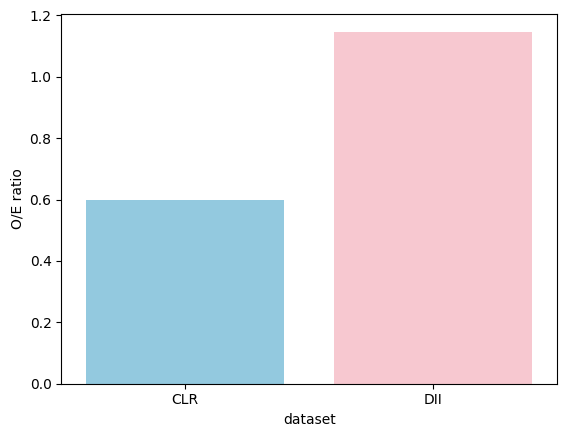

In [22]:
sns.barplot(x="dataset", y="O/E ratio", data=immsup_both, palette=["skyblue", "pink"])
plt.show()

Compute per-FOV motif frequency to test whether the immunosuppressive motif is differentially
present between CLR and DII (Mann-Whitney U test).

In [23]:
freq = {clr: [], dii: []}

for sp in spm.spatial_queries:
    sp_ds_name = sp.dataset.split("_")[0]
    if anchor_ct not in sp.labels.values:
        continue

    out = sp.motif_enrichment_dist(
        ct=anchor_ct, motifs=motif_immsup, max_dist=max_dist, return_cellID=False,
    )
    if len(out) == 0:
        continue

    ratio = out["n_center_motif"] / out["n_center"]
    if isinstance(ratio, (pd.Series, np.ndarray)):
        ratio = ratio.iloc[0] if hasattr(ratio, "iloc") else ratio.item()

    freq[sp_ds_name].append(float(ratio))

Found no ['Tregs'] in ClusterName. Ignoring them.
Found no ['Tregs'] in ClusterName. Ignoring them.
Found no ['Tregs'] in ClusterName. Ignoring them.
Found no ['Tregs'] in ClusterName. Ignoring them.
Found no ['Tregs'] in ClusterName. Ignoring them.
Found no ['Tregs'] in ClusterName. Ignoring them.
Found no ['Tregs'] in ClusterName. Ignoring them.


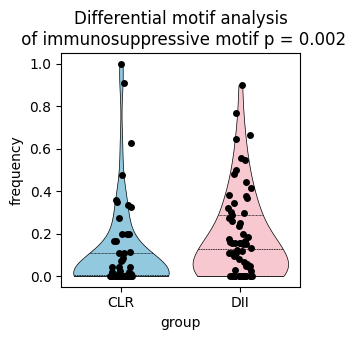

In [24]:

plot_df = pd.DataFrame({
    'group': (
        [clr] * len(freq[clr]) +
        [dii] * len(freq[dii])
    ),
    'frequency': (
        freq[clr] +
        freq[dii]
    )
})

from scipy import stats
group1 = freq[clr]
group2 = freq[dii]
stat, p_value = stats.mannwhitneyu(group1, group2,
                                   alternative='two-sided',
                                   method='auto')

fig, ax = plt.subplots(figsize=(3.2, 3.5))

# Violin
sns.violinplot(
    data=plot_df,
    x="group",
    y="frequency",
    ax=ax,
    cut=0,
    inner="quartile",
    linewidth=0.5,
    edgecolor='black',
    palette=["skyblue", "pink"] 
)

# Overlay points
sns.stripplot(
    data=plot_df,
    x="group",
    y="frequency",
    ax=ax,
    color="black",
    size=5,
    jitter=0.1,
)

ax.set_title(f'Differential motif analysis\n of immunosuppressive motif p = {p_value:.3f}')

plt.tight_layout()


